# To discover correlations after to apply a series of transformations to index under certain frequencies 

In [363]:
import pandas as pd
import numpy as np 
import seaborn as sns

In [364]:
series = pd.read_csv('../Data/Preprocessed/HUPA0011P.csv', sep=';')['glucose'][:2290]

In [365]:
series

0        75.000000
1        76.000000
2        83.666667
3        91.333333
4        99.000000
           ...    
2285    241.666667
2286    248.333333
2287    255.000000
2288    259.666667
2289    264.333333
Name: glucose, Length: 2290, dtype: float64

In [366]:
new_data = {}
frequencies = [0.0005, 0.00069, 0.000611, 0.0011, 0.0034]
days_freq = {0.00069:5, 0.000611:5.6, 0.0005:7, 0.0011:3, 0.0034:1}
for f_i in frequencies:
    c_i = 2 * np.pi * f_i * series.index
    sin_c_i = np.sin(c_i)
    cos_ci = np.cos(c_i)
    new_data[f'f_{days_freq[f_i]}_days_cos'] = cos_ci
    new_data[f'f_{days_freq[f_i]}_days_sen'] = sin_c_i
new_data['glucose'] = series.values
    

In [367]:
data_transformed = pd.DataFrame(new_data)
corr_matrix = data_transformed.corr(numeric_only=True)


In [368]:
corr_matrix['glucose'].sort_values(ascending=False)

glucose           1.000000
f_1_days_cos      0.147358
f_3_days_sen      0.125208
f_5_days_cos     -0.025963
f_7_days_sen     -0.047248
f_5.6_days_cos   -0.117168
f_7_days_cos     -0.126562
f_5.6_days_sen   -0.144768
f_3_days_cos     -0.181343
f_5_days_sen     -0.212665
f_1_days_sen     -0.252781
Name: glucose, dtype: float64

<Axes: >

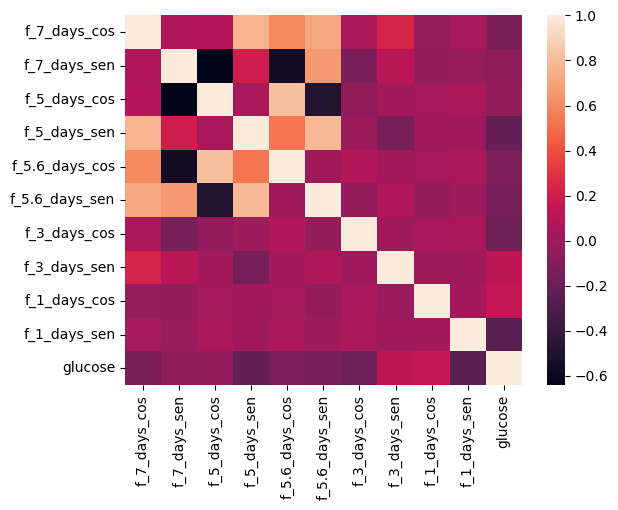

In [369]:
sns.heatmap(corr_matrix)

## Test it 


In [370]:
import sys
import os

project_root = os.path.abspath("..") 
sys.path.append(project_root)

from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [371]:
class Window_Regressor_Postional_Frequentist_Encoding:
    def __init__(self, time_series_data: pd.Series, window_size: int, horizon: int, freq_to_compute:int):
        self.time_series_data = time_series_data
        self.window_size = window_size
        self.horizon = horizon
        self.max_freq = freq_to_compute
        self.generated_data_set = self.generate_data_set()


    def compute_coefficients(self, zt, frequencies):
        T = len(zt)
        t = np.arange(T)
        
        omega_t = 2 * np.pi * frequencies.reshape(-1, 1) * t
        
        a_j = (2/T) * np.sum(zt.values * np.sin(omega_t), axis=1)
        b_j = (2/T) * np.sum(zt.values * np.cos(omega_t), axis=1)
        
        return a_j, b_j

    def periodogram(self):
        zt = self.time_series_data
        T = len(zt)
        num_freq = T//2 + 1
        frequencies = np.linspace(1/T, 0.1, num=num_freq, dtype=np.float32)
        
        a_j, b_j = self.compute_coefficients(zt, frequencies)
        periodogram = (T/2) * (np.square(a_j) + np.square(b_j))
        return dict(zip(frequencies, periodogram))

    def create_data_frame(self):
        # Firstly, we compute the top patient's frequencies
        frequencies_dict = self.periodogram()
        top_frequencies = sorted(frequencies_dict.items(), key=lambda x: x[1], reverse=True)[:self.max_freq]
        top_frequencies = {freq:(1/freq)/288 for freq, peridogram_value in top_frequencies} ## To get a dict freq :days
        self.top_frequencies = top_frequencies

        data = {}
        positions = self.time_series_data.index
        for freq, days in self.top_frequencies.items():
            c_i = 2 * np.pi * freq * positions
            sen_i = np.sin(c_i)
            cos_i = np.cos(c_i)
            
            data[f'f_{days}_sin'] = sen_i
            data[f'f_{days}_cos'] = cos_i
        data['glucose'] = self.time_series_data.values
        return pd.DataFrame(data)
    
    
    def generate_data_set(self):
        data_with_seasonal_columns = self.create_data_frame()
        n = self.time_series_data.shape[0]
        m = self.window_size
        data = []
        
        for i in range(n - (m+self.horizon) + 1):
            window_i = []
            for j in range(i, i + m):
                window_i.append(list(data_with_seasonal_columns.iloc[j].values))

            window_i = np.array(window_i)
            window_i = list(window_i.flatten())

            target_idx = j + self.horizon
            window_i.append(self.time_series_data.iloc[target_idx])
            data.append(window_i)
        
        num_predictors = m*data_with_seasonal_columns.shape[1]
        columns = [f'Predictor_{c}' for c in range(num_predictors)] + ['Target']
        return pd.DataFrame(data, columns=columns)

In [372]:
transfomer = Window_Regressor_Postional_Frequentist_Encoding(time_series_data=series, window_size=72, horizon=12, freq_to_compute=10)

In [373]:
data_created = transfomer.create_data_frame()
corr_matrix = data_created.corr()
corr_matrix['glucose'].sort_values(ascending = False)

glucose                     1.000000
f_2.345874786376953_cos     0.238198
f_3.321539878845215_sin     0.186165
f_2.2157068252563477_cos    0.184154
f_3.622897148132324_sin     0.149683
f_2.4922914505004883_cos    0.137782
f_3.622897148132324_cos     0.110969
f_2.2157068252563477_sin    0.102114
f_3.066466808319092_sin     0.060881
f_4.977769374847412_cos    -0.014823
f_6.630983829498291_sin    -0.063673
f_2.345874786376953_sin    -0.064913
f_3.321539878845215_cos    -0.075081
f_5.6866583824157715_cos   -0.117474
f_6.630983829498291_cos    -0.132870
f_2.847776174545288_sin    -0.141942
f_5.6866583824157715_sin   -0.144332
f_4.977769374847412_sin    -0.214828
f_2.847776174545288_cos    -0.219882
f_3.066466808319092_cos    -0.221209
f_2.4922914505004883_sin   -0.230204
Name: glucose, dtype: float64

In [374]:
data_to_train = transfomer.generated_data_set

In [375]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [376]:
data_simple_linear_regression = Window_Regressor_Sequence_to_scalar(time_series_data=series, window_size=12, horizon=12).generate_data_set().values
X_linear, y_linear = data_simple_linear_regression[:, :-1], data_simple_linear_regression[:, -1]
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(X_linear, y_linear, test_size=0.2, shuffle=False) 

In [377]:
X = data_to_train.values[:, :-1]
y = data_to_train.values[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [378]:
model =  LassoCV(
            alphas=np.linspace(0.01, 1, 50),
            cv=5,
            max_iter=10000
        )
model_simple_linear = LinearRegression()
model_simple_linear.fit(X_train_linear, y_train_linear)
print(model.fit(X_train, y_train))

/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.119e+02, tolerance: 4.979e+02
  model = cd_fast.enet_coordinate_descent(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.585e+03, tolerance: 4.979e+02
  model = cd_fast.enet_coordinate_descent(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality 

LassoCV(alphas=array([0.01      , 0.03020408, 0.05040816, 0.07061224, 0.09081633,
       0.11102041, 0.13122449, 0.15142857, 0.17163265, 0.19183673,
       0.21204082, 0.2322449 , 0.25244898, 0.27265306, 0.29285714,
       0.31306122, 0.33326531, 0.35346939, 0.37367347, 0.39387755,
       0.41408163, 0.43428571, 0.4544898 , 0.47469388, 0.49489796,
       0.51510204, 0.53530612, 0.5555102 , 0.57571429, 0.59591837,
       0.61612245, 0.63632653, 0.65653061, 0.67673469, 0.69693878,
       0.71714286, 0.73734694, 0.75755102, 0.7777551 , 0.79795918,
       0.81816327, 0.83836735, 0.85857143, 0.87877551, 0.89897959,
       0.91918367, 0.93938776, 0.95959184, 0.97979592, 1.        ]),
        cv=5, max_iter=10000)


In [379]:
y_pred = model.predict(X_test)
y_pred_linear = model_simple_linear.predict(X_test_linear)

mse_linear = mean_squared_error(y_test_linear, y_pred_linear)
mae_linear = mean_absolute_error(y_test_linear, y_pred_linear)
mape_linear = mean_absolute_percentage_error(y_test_linear, y_pred_linear)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'MAE : {mae}')
print(f'MSE : {mse}')
print(f'MAPE : {mape}')
print()
print(f'MAE_linear : {mae_linear}')
print(f'MSE_linear : {mse_linear}')
print(f'MAPE linear : {mape_linear}')

MAE : 29.454774096609338
MSE : 1304.3944699832798
MAPE : 0.17876201469012032

MAE_linear : 27.08653088741828
MSE_linear : 1303.4424173250763
MAPE linear : 0.1609299582813785


In [380]:
print(y_test_linear.shape)
print(y_test.shape)

(454,)
(442,)
